In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('Feature_Engineered_Online_Retail.csv')
rfm = pd.read_csv('customer_level_features.csv')

In [47]:
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 18
})

In [52]:
def currency_formatter(x, pos):
    """Formats large monetary numbers into beautiful $M or $K notation."""
    if x >= 1e6:
        return f"${x*1e-6:.1f}M"
    elif x >= 1e3:
        return f"${x*1e-3:.0f}K"
    return f"${x:.0f}"

def count_formatter(x, pos):
    """Formats large counts with standard K notation."""
    if x >= 1e3:
        return f"{x*1e-3:.0f}K"
    return f"{x:.0f}"


In [53]:
def calculate_comprehensive_kpis(df):
    """Calculates full range of business KPIs."""
    net_df = df[~df['IsCancellation']]
    
    # Revenue Metrics
    total_rev = net_df['LineTotal'].sum()
    total_orders = net_df['InvoiceNo'].nunique()
    total_customers = net_df['CustomerID'].nunique()
    aov = total_rev / total_orders
    
    # Retention Metric
    repeat_customers = net_df.groupby('CustomerID')['InvoiceNo'].nunique()
    retention_rate = (repeat_customers[repeat_customers > 1].count() / total_customers) * 100
    
    # Return / Cancellation Metric
    total_canceled_orders = df[df['IsCancellation']]['InvoiceNo'].nunique()
    total_all_orders = df['InvoiceNo'].nunique()
    cancellation_rate = (total_canceled_orders / total_all_orders) * 100
    
    print("==========================================")
    print("   COMPREHENSIVE BUSINESS KPI SUMMARY     ")
    print("==========================================")
    print(f"Total Net Revenue:     ${total_rev:,.2f}")
    print(f"Total Unique Orders:   {total_orders:,}")
    print(f"Total Unique Customers: {total_customers:,}")
    print(f"Average Order Value:   ${aov:,.2f}")
    print(f"Customer Retention:    {retention_rate:.2f}%")
    print(f"Order Cancellation Rate:{cancellation_rate:.2f}%")
    print("==========================================")


In [60]:
from matplotlib.ticker import FuncFormatter

In [61]:
def plot_dashboard(df, rfm):
    """Generates an advanced 9-panel analytical dashboard for Hackathon showcases."""
    fig, axes = plt.subplots(3, 3, figsize=(28, 22))
    fig.suptitle("E-Commerce Customer Purchase Pattern Dashboard (9-Panel Deep Dive)", weight='bold', y=0.98)
    
    # Filter for non-cancellations for revenue-based plots
    net_df = df[~df['IsCancellation']].copy()
    
    # ================= ROW 1: TEMPORAL FLOWS & PEAKS =================
    
    # 1. Monthly Revenue & Order Volume Trends
    ax1 = axes[0, 0]
    monthly_stats = net_df.groupby('OrderMonth').agg(
        Revenue=('LineTotal', 'sum'),
        Orders=('InvoiceNo', 'nunique')
    ).reset_index()
    
    sns.barplot(data=monthly_stats, x='OrderMonth', y='Revenue', ax=ax1, color='teal', alpha=0.8)
    ax1.set_title('Monthly Net Revenue & Order Volume')
    ax1.set_ylabel('Net Revenue ($)')
    ax1.set_xlabel('Month of Year')
    ax1.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
    
    # Dual axis for Order Volume line
    ax1_twin = ax1.twinx()
    sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='Orders', ax=ax1_twin, color='darkorange', marker='o', linewidth=2.5, label='Order Volume')
    ax1_twin.set_ylabel('Total Orders')
    ax1_twin.grid(False)
    ax1_twin.yaxis.set_major_formatter(FuncFormatter(count_formatter))
    
    # 2. Temporal Heatmap: Order Volume (Hour vs Day)
    ax2 = axes[0, 1]
    heatmap_data = df.groupby(['DayOfWeek', 'OrderHour']).size().unstack(fill_value=0)
    sns.heatmap(heatmap_data, ax=ax2, cmap='YlGnBu', cbar_kws={'label': 'Order Count', 'format': FuncFormatter(count_formatter)})
    ax2.set_title('Peak Shopping Hours (Day of Week vs. Hour)')
    ax2.set_xlabel('Hour of the Day')
    ax2.set_ylabel('')
    
    # 3. Time of Day Segment Revenue Pattern
    ax3 = axes[0, 2]
    time_of_day_stats = net_df.groupby('TimeOfDay').agg(
        TotalRevenue=('LineTotal', 'sum')
    ).reset_index()
    
    time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
    time_of_day_stats['TimeOfDay'] = pd.Categorical(time_of_day_stats['TimeOfDay'], categories=time_order, ordered=True)
    time_of_day_stats = time_of_day_stats.sort_values('TimeOfDay')
    
    sns.lineplot(data=time_of_day_stats, x='TimeOfDay', y='TotalRevenue', marker='s', color='crimson', linewidth=3.5, ax=ax3)
    ax3.set_ylabel('Revenue ($)')
    ax3.set_xlabel('Time of Day')
    ax3.set_title('Sales Patterns by Time of Day')
    ax3.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

    # ================= ROW 2: CUSTOMER BEHAVIOR & SEGMENTATION =================

    # 4. RFM Segments: Average Revenue Contribution
    ax4 = axes[1, 0]
    segment_value = rfm.groupby('RFM_Segment')['Monetary'].mean().reset_index()
    # Pull top 10 highest-value segments to keep the visualization crisp
    top_segments = segment_value.sort_values('Monetary', ascending=False).head(10)
    sns.barplot(data=top_segments, x='Monetary', y='RFM_Segment', ax=ax4, palette='viridis_r')
    ax4.set_title('Top 10 RFM Segments by Avg Spend')
    ax4.set_xlabel('Average Customer Monetary Spend ($)')
    ax4.set_ylabel('RFM Segment Group')
    ax4.xaxis.set_major_formatter(FuncFormatter(currency_formatter))

    # 5. Customer Profiles: Recency vs. Monetary
    ax5 = axes[1, 1]
    monetary_cap = rfm['Monetary'].quantile(0.98) # Keep outliers from skewing scale
    clean_rfm = rfm[rfm['Monetary'] <= monetary_cap]
    
    scatter = sns.scatterplot(
        data=clean_rfm, 
        x='Recency', 
        y='Monetary', 
        hue='Frequency', 
        size='Frequency',
        sizes=(20, 200),
        palette='crest', 
        ax=ax5, 
        alpha=0.7
    )
    ax5.set_title('Customer Matrix: Recency vs. Spend')
    ax5.set_xlabel('Recency (Days since last order)')
    ax5.set_ylabel('Total Monetary Spend ($)')
    ax5.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

    # 6. Top 10 Best Selling Products by Net Revenue
    ax6 = axes[1, 2]
    top_products = net_df.groupby('Description')['LineTotal'].sum().nlargest(10).reset_index()
    sns.barplot(data=top_products, x='LineTotal', y='Description', ax=ax6, palette='magma')
    ax6.set_title('Top 10 Products by Net Revenue')
    ax6.set_xlabel('Total Net Revenue ($)')
    ax6.set_ylabel('')
    ax6.xaxis.set_major_formatter(FuncFormatter(currency_formatter))

    # ================= ROW 3: BASKET DYNAMICS & OPERATIONAL METRICS =================

    # 7. Weekday vs Weekend Basket Performance
    ax7 = axes[2, 0]
    weekend_behavior = net_df.groupby('IsWeekend').agg(
        AvgBasketValue=('BasketValue', 'mean'),
        AvgBasketSize=('BasketSize', 'mean')
    ).reset_index()
    weekend_behavior['IsWeekend_Label'] = weekend_behavior['IsWeekend'].map({0: 'Weekday', 1: 'Weekend'})
    
    x_coords = np.arange(len(weekend_behavior))
    width = 0.35
    
    ax7.bar(x_coords - width/2, weekend_behavior['AvgBasketValue'], width, label='Avg Value ($)', color='royalblue', alpha=0.8)
    ax7_twin = ax7.twinx()
    ax7_twin.bar(x_coords + width/2, weekend_behavior['AvgBasketSize'], width, label='Avg Size (Qty)', color='orange', alpha=0.8)
    
    ax7.set_title('Average Order metrics: Weekdays vs. Weekends')
    ax7.set_xticks(x_coords)
    ax7.set_xticklabels(weekend_behavior['IsWeekend_Label'])
    ax7.set_ylabel('Average Basket Value ($)')
    ax7_twin.set_ylabel('Average Basket Size (Qty)')
    ax7_twin.grid(False)
    ax7.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
    
    # Merge legeneds
    lines1, labels1 = ax7.get_legend_handles_labels()
    lines2, labels2 = ax7_twin.get_legend_handles_labels()
    ax7.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    # 8. Distribution of Basket Sizes (Order Depth Analysis)
    ax8 = axes[2, 1]
    basket_cap = net_df['BasketSize'].quantile(0.95) # Filter major wholesale outliers to see curves cleanly
    clean_baskets = net_df[net_df['BasketSize'] <= basket_cap]
    
    sns.histplot(data=clean_baskets, x='BasketSize', kde=True, color='purple', ax=ax8, bins=25)
    ax8.set_title('Distribution of Order Basket Sizes')
    ax8.set_xlabel('Items per Basket (Quantity)')
    ax8.set_ylabel('Frequency')

    # 9. Top 5 Countries by Order Cancellation Rate
    ax9 = axes[2, 2]
    invoice_countries = df.groupby(['InvoiceNo', 'Country', 'IsCancellation']).size().reset_index()
    country_stats = invoice_countries.groupby('Country').agg(
        Total_Orders=('InvoiceNo', 'nunique'),
        Cancelled_Orders=('IsCancellation', 'sum')
    ).reset_index()
    # Filter countries with minimal transactions to avoid biased smaller sample scales
    country_stats = country_stats[country_stats['Total_Orders'] >= 15]
    country_stats['CancellationRate'] = (country_stats['Cancelled_Orders'] / country_stats['Total_Orders']) * 100
    top_cancelled_countries = country_stats.sort_values('CancellationRate', ascending=False).head(5)
    
    sns.barplot(data=top_cancelled_countries, x='CancellationRate', y='Country', ax=ax9, palette='coolwarm')
    ax9.set_title('Top 5 Countries by Order Returns %')
    ax9.set_xlabel('Cancellation Rate (%)')
    ax9.set_ylabel('')

    # Clean layout optimization
    plt.tight_layout()
    plt.subplots_adjust(top=0.92) # Leave space for the main suptitle
    plt.show()

In [62]:
sns.set_theme(style="whitegrid")

   COMPREHENSIVE BUSINESS KPI SUMMARY     
Total Net Revenue:     $10,644,560.42
Total Unique Orders:   19,962
Total Unique Customers: 4,339
Average Order Value:   $533.24
Customer Retention:    65.59%
Order Cancellation Rate:16.12%


C:\Users\madda\AppData\Local\Temp\ipykernel_3788\1983039883.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_segments, x='Monetary', y='RFM_Segment', ax=ax4, palette='viridis_r')
C:\Users\madda\AppData\Local\Temp\ipykernel_3788\1983039883.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='LineTotal', y='Description', ax=ax6, palette='magma')
C:\Users\madda\AppData\Local\Temp\ipykernel_3788\1983039883.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cancelled_countries, x='CancellationRate', 

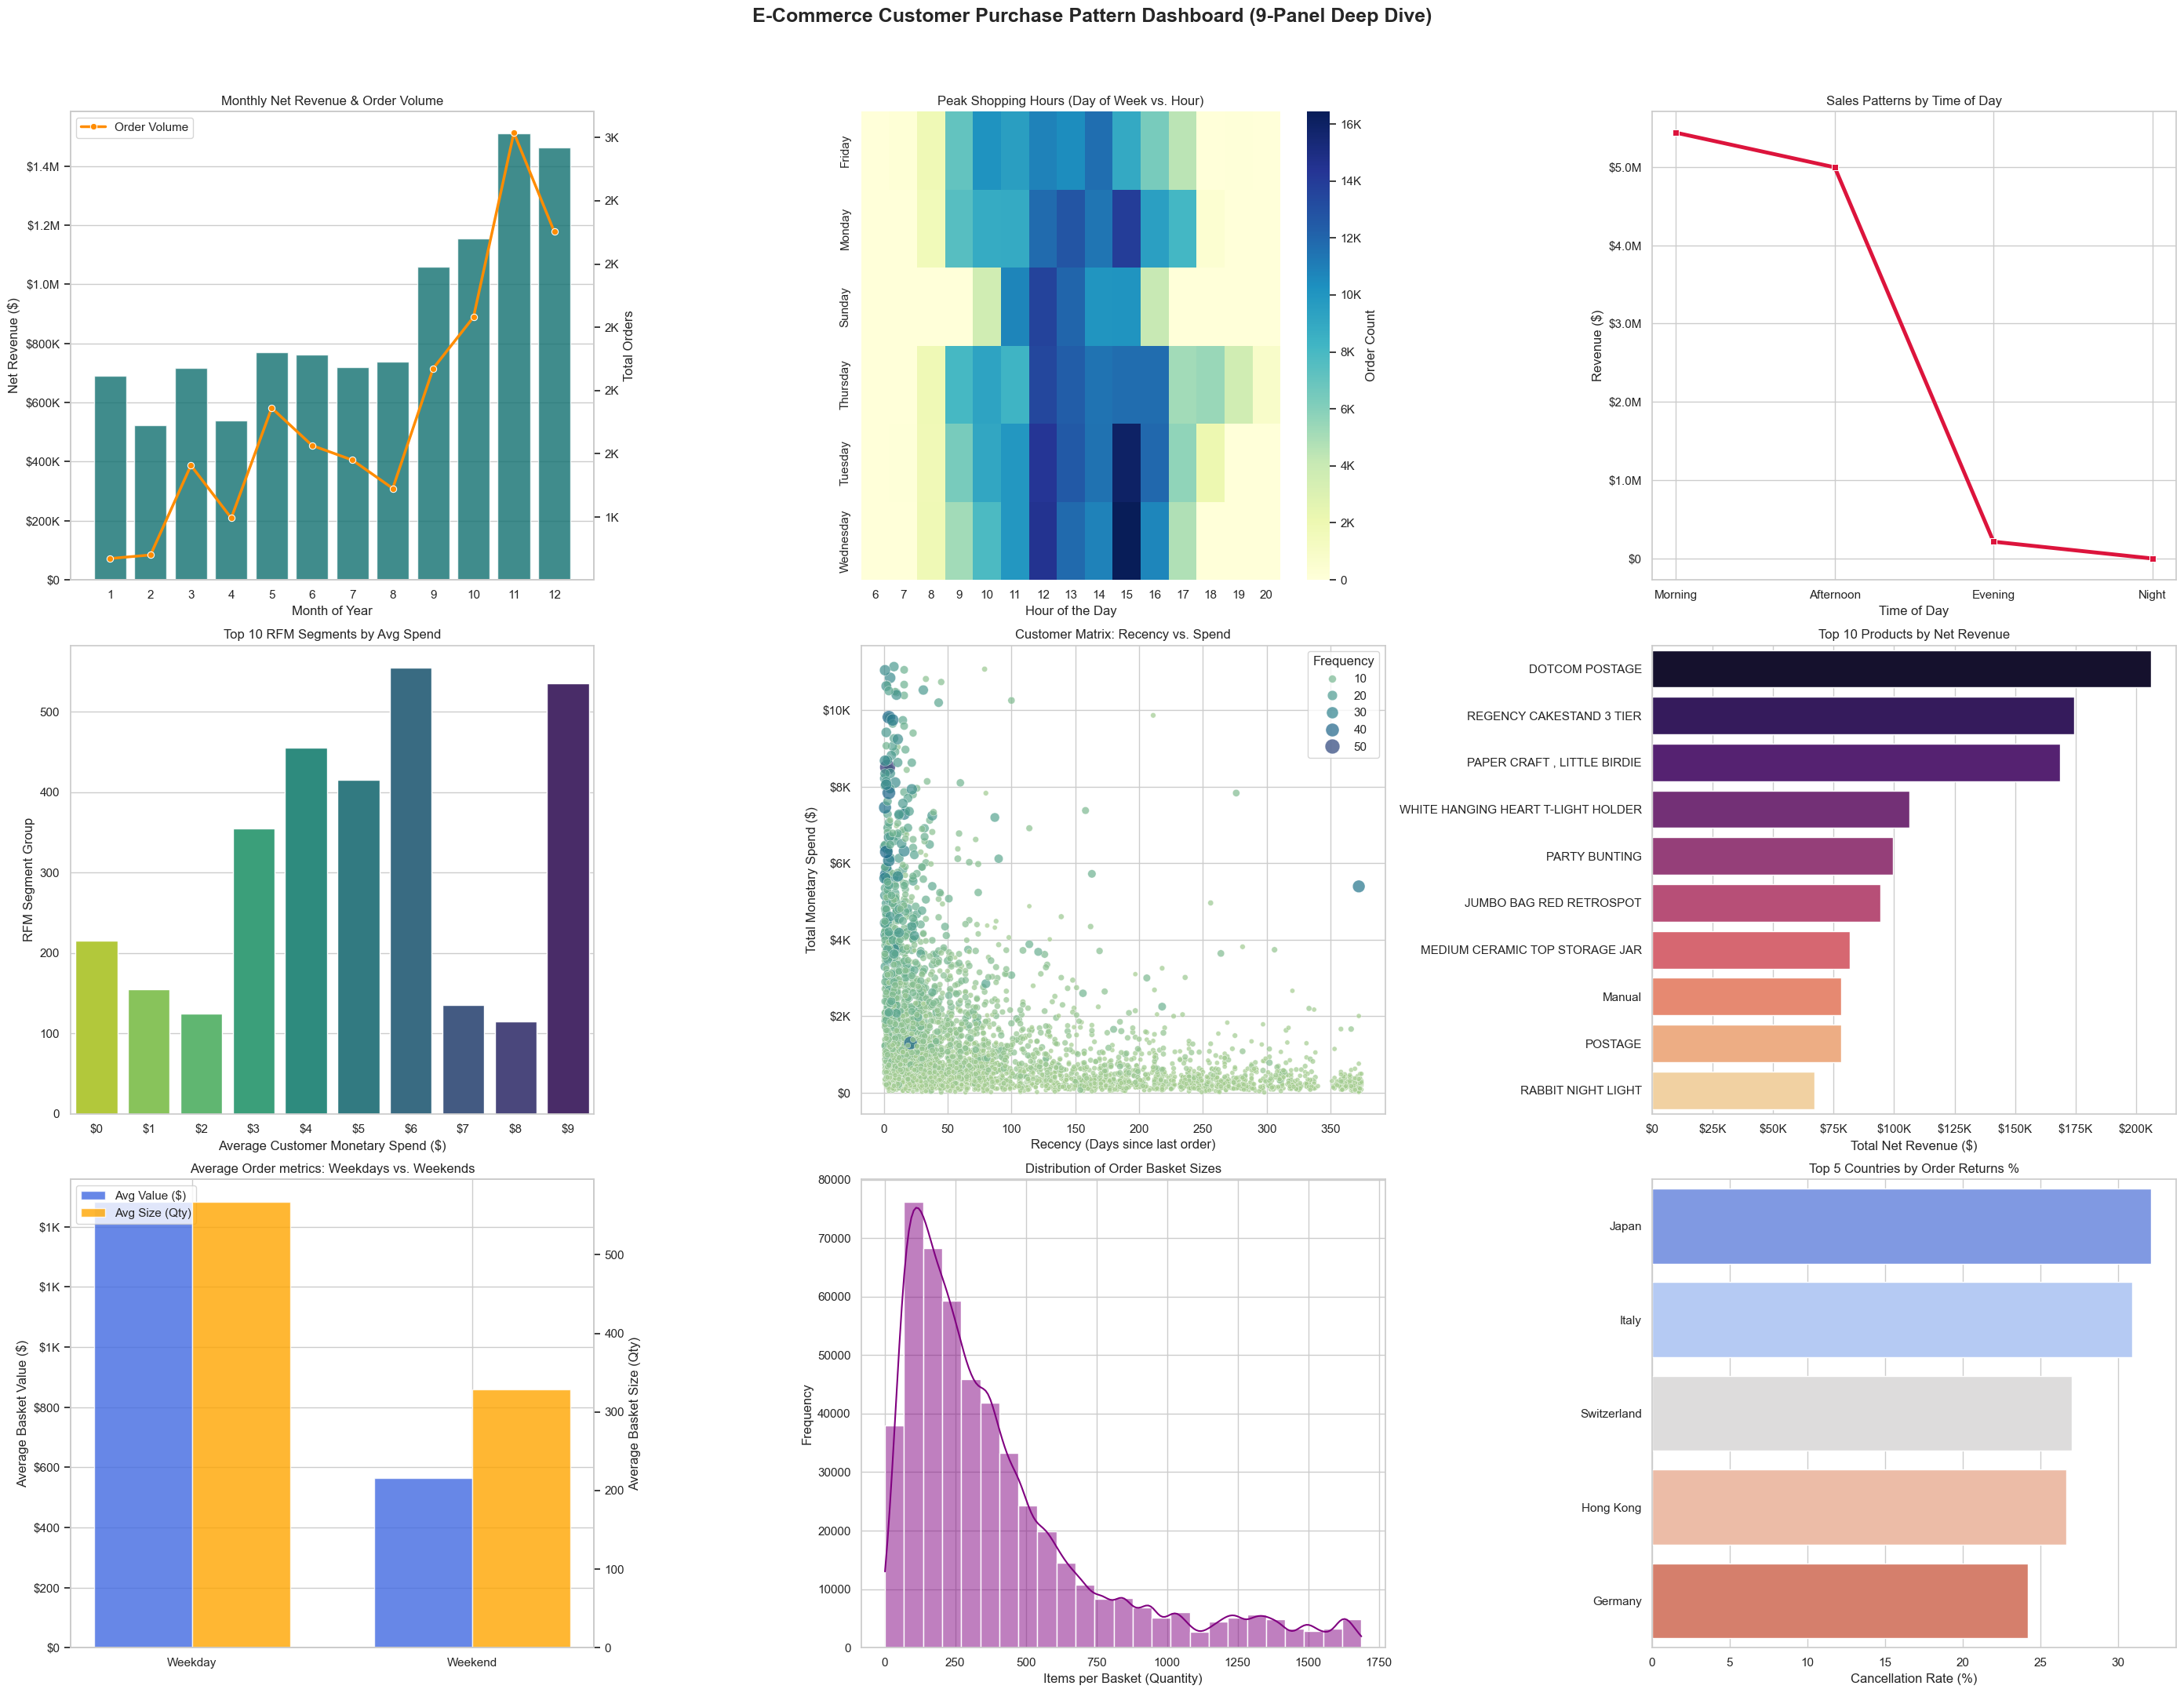

In [63]:
calculate_comprehensive_kpis(df)
plot_dashboard(df, rfm)